In [2]:
import numpy as np 
import pandas as pd
from src import utils, redcells, db
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2
ROOT_PATH = "Z:/data/PROC"
RET_PATH = "D:/retinotopy/aligned_xy/behav"
MDL_PATH = "D:/mouseobj/"

In [3]:
db_ = []
db_.append({'mname': 'VG56', 'datexp': '2026_07_15', 'blk':'3','stim':'short3'})
db_.append({'mname': 'VG58', 'datexp': '2026_07_15', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG59', 'datexp': '2026_07_15', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG70', 'datexp': '2026_08_13', 'blk':'3','stim':'8x2task'}) #3
db_.append({'mname': 'VG69', 'datexp': '2026_08_14', 'blk':'2','stim':'8x2task'})
db_.append({'mname': 'VG66', 'datexp': '2026_08_13', 'blk':'2','stim':'8x2task'})
db_.append({'mname': 'VG64', 'datexp': '2026_08_14', 'blk':'2','stim':'8x2task'})
db_.append({'mname': 'VG63', 'datexp': '2026_08_14', 'blk':'2','stim':'8x2task'})
db_ = pd.DataFrame(db_)

In [1]:
from scipy.stats import zscore

def signal_variance(stim_resp):
    NN = stim_resp.shape[0]
    nstim = stim_resp.shape[1]
    nreps = stim_resp.shape[2]
    s2 = np.zeros((2, nstim, NN), 'float32')
    for j in range(nstim):
        s2[0, j] = stim_resp[:, j, ::2].mean(1)
        s2[1, j] = stim_resp[:, j, 1::2].mean(1)
    ss = s2 - np.mean(s2,1)[:,np.newaxis,:]
    ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5
    csig = (ss[0] * ss[1]).mean(0)
    return csig

def get_stim_response_mtx(m, segment=(0, 100), z=False):
    avg_resp = np.mean(m.interp_spks[:,:,segment[0]:segment[1]], axis=2)
    if z:
        avg_resp = zscore(avg_resp, axis=1)
    nreps = m.frameselector.groupby(['istim']).trial_no.nunique().values.min()
    resp_stim_rep = np.full((avg_resp.shape[0], 16, nreps), np.nan)
    for i in range(1,17):
        trials = m.frameselector.query(f'istim == {i}').trial_no.unique() - 1 
        trials = trials[:nreps].astype(int)
        resp_stim_rep[:,i-1, :] = avg_resp[:,trials]
    return resp_stim_rep

def filter_neurons(m, area=None, plane=0, ctype="exc"):
    ix_area = np.isin(m.iarea, area)
    if plane == 1:
        ix_plane = (m._iplane >= 10) #deep 
    elif plane == 2:
        ix_plane = (m._iplane < 10) #sup
    elif plane == 0:
        ix_plane = np.ones_like(m._iplane, dtype=bool)
    else:
        raise ValueError("Layer must be 1 or 2 for depths, or 0 for all planes")
    if ctype == "exc":
        ix_type = ~m.isred[:,0].astype(bool)
    elif ctype == "inh":
        ix_type = m.isred[:,0].astype(bool)
    else:
        raise ValueError("Cell type must be 'exc' or 'inh'")
    return ix_area, ix_plane, ix_type

In [26]:
df_counts = []
small_areas = np.array([8,0,1,2,9,3,4,5,6,7])
areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
overall_mtx = np.full((db_.shape[0], len(small_areas), 2, 16, 16), np.nan)
for i, row in db_.iterrows():
    name, datexp, blk = row['mname'], row["datexp"], row["blk"]    
    m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, return_iscell=True,
                        data_path=ROOT_PATH, ret_path=RET_PATH,  mdl_path=MDL_PATH, opt_tlag = 1)
    stim_resp = get_stim_response_mtx(m, segment=(0, 100), z=True)
    cc = signal_variance(stim_resp)
    for iarea, a in enumerate(small_areas):
        for ic, ctype in enumerate(["exc", "inh"]):
            ia, ip, it = filter_neurons(m, area=a, plane=0, ctype=ctype)
            selection = ia & ip & it
            tsh = np.nanpercentile(cc[selection], 90)
            sel = selection & (cc >= tsh)
            df_counts.append({'mouse': m.name, 'area': areas_names[iarea], 'area_n': np.sum(ia), 'cell_type': ctype, 'area_ct_n': np.sum(ia&it), 'area_ct_n_pctile': np.sum(sel)})
df_counts = pd.DataFrame(df_counts)
df_counts.to_csv(Path(r"C:\Users\labadmin\Documents\category-neural\scripts\rsm_passive").joinpath("closed_loop_neural_counts.csv"), index=False)

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG56\2026_07_15\3
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])


C:\Users\labadmin\AppData\Local\Temp\ipykernel_4196\2207185099.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  avg_resp = zscore(avg_resp, axis=1)
C:\Users\labadmin\AppData\Local\Temp\ipykernel_4196\2207185099.py:12: RuntimeWarning: invalid value encountered in divide
  ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5


Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG58\2026_07_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])


c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1619: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG59\2026_07_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])


...

C:\Users\labadmin\AppData\Local\Temp\ipykernel_4196\2207185099.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  avg_resp = zscore(avg_resp, axis=1)
C:\Users\labadmin\AppData\Local\Temp\ipykernel_4196\2207185099.py:12: RuntimeWarning: invalid value encountered in divide
  ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5


Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG64\2026_08_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])


C:\Users\labadmin\AppData\Local\Temp\ipykernel_4196\2207185099.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  avg_resp = zscore(avg_resp, axis=1)
C:\Users\labadmin\AppData\Local\Temp\ipykernel_4196\2207185099.py:12: RuntimeWarning: invalid value encountered in divide
  ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5


Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG63\2026_08_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks'])


C:\Users\labadmin\AppData\Local\Temp\ipykernel_4196\2207185099.py:12: RuntimeWarning: invalid value encountered in divide
  ss = ss / np.mean(ss**2,1)[:,np.newaxis,:]**.5


In [27]:
df_counts

,mouse,area,area_n,cell_type,area_ct_n,area_ct_n_pctile
0,VG56,VISp,14206,exc,13555,1356
1,VG56,VISp,14206,inh,651,66
2,VG56,VISpm,1585,exc,1499,150
3,VG56,VISpm,1585,inh,86,9
4,VG56,VISam,865,exc,803,81
...,...,...,...,...,...,...
155,VG63,VISlm,872,inh,37,4
156,VG63,VISal,828,exc,790,79
157,VG63,VISal,828,inh,38,4
158,VG63,VISlla,493,exc,476,48


In [28]:
df_counts.area.unique()

array(['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll',
       'VISlm', 'VISal', 'VISlla'], dtype=object)

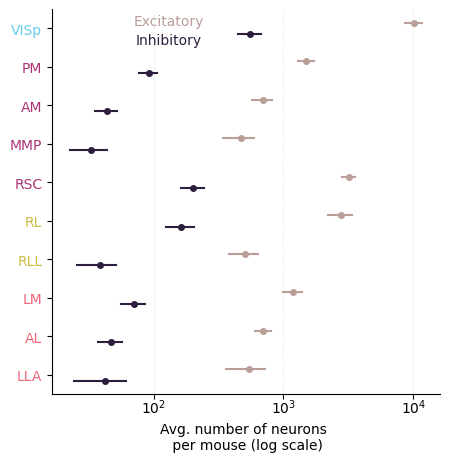

In [32]:
import matplotlib.ticker as ticker
fig, ax = plt.subplots(figsize=(5,5))
ax = sns.pointplot(data=df_counts, y='area', x='area_ct_n', hue='cell_type', palette=["#BA9E98", "#2D1E3E"],
                dodge=0.3, markersize=3, errorbar=('se'), err_kws={'linewidth': 1.5}, legend=False, linestyle="none")
ax.set_xscale('log')
ax.grid(True, which="both", ls="--", alpha=0.2, axis='x')
#custom_ticks = [500, 1000, 2000, 5000, 10000] 
#ax.set_xticks(custom_ticks)
#ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.tick_params(axis='x', which='major', pad=-1)
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylabel("")
ax.set_xlabel("Avg. number of neurons \n per mouse (log scale)");
ax.text(0.3, 0.97, "Excitatory", color="#BA9E98", rotation=0, ha='center', va='center', transform=ax.transAxes)
ax.text(0.3, 0.92, "Inhibitory", color="#2D1E3E", rotation=0, ha='center', va='center', transform=ax.transAxes)
tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
for tlabel, tcolor in zip(ax.get_yticklabels(), tcolors):
    tlabel.set_color(tcolor)
labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
ax.set_yticks(ax.get_yticks());
sns.despine()
ax.set_yticklabels(labels_, ha='right');

In [30]:
def plot_neuron_counts(df_counts, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    ax = sns.pointplot(data=df_counts, y='area', x='area_ct_n', hue='cell_type', palette=["#BA9E98", "#2D1E3E"],
                    dodge=0.3, markersize=3, errorbar=('se'), err_kws={'linewidth': 1.5}, legend=False, linestyle="none", ax=ax)
    ax.set_xscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.2, axis='x')
    ax.tick_params(axis='x', which='major', pad=-1)
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.set_ylabel("")
    ax.set_xlabel("Avg. number of neurons \n per mouse (log scale)");
    ax.text(0.3, 0.97, "Excitatory", color="#BA9E98", rotation=0, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.3, 0.92, "Inhibitory", color="#2D1E3E", rotation=0, ha='center', va='center', transform=ax.transAxes)
    tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
    for tlabel, tcolor in zip(ax.get_yticklabels(), tcolors):
        tlabel.set_color(tcolor)
    labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
    ax.set_yticks(ax.get_yticks());
    ax.set_yticklabels(labels_, ha='right')
    sns.despine()

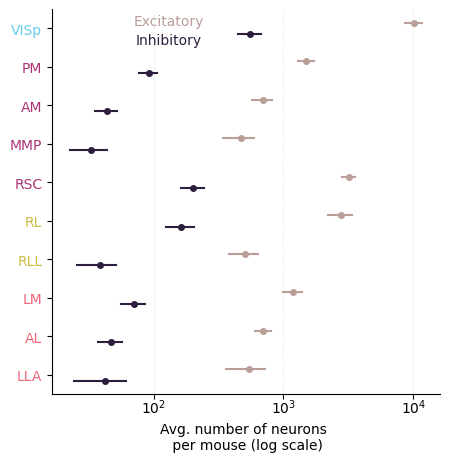

In [33]:
fig, ax = plt.subplots(figsize=(5,5))
plot_neuron_counts(df_counts, ax=ax)

In [17]:
n_area_type = 13555
target_n = min(n_area_type, max(100, int(np.ceil(0.1 * n_area_type))))

In [18]:
int(np.ceil(0.1 * n_area_type))

1356

In [19]:
target_n

1356

In [20]:
1 - target_n / n_area_type

0.899963113242346

In [16]:
if target_n == n_area_type:
    sel = selection
else:
    # Find the threshold value for the top `target_n` elements
    sub_cc = cc[selection]
    tsh = np.nanpercentile(sub_cc, 100 * (1 - target_n / n_area_type))
    sel = selection & (cc >= tsh)